In [1]:
# Task 6: Integrative Capstone Project
# Air Quality Analysis and CO(GT) Prediction

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)


Libraries imported successfully.


In [2]:
# Load cleaned Air Quality dataset

DATA_PATH = r"C:\Users\harsh\YuvaIntern_Data_Science_Project\task1_air_quality\outputs\air_quality_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (9357, 13)


,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
# Basic dataset inspection

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (9357, 13)

Columns:
['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Missing Values:
Datetime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Data Types:
Datetime             str
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

Statistical Summary:


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.089302,1098.392433,10.009447,937.973923,235.178903,834.339959,112.373303,1456.528054,1020.562894,18.297574,49.248509,1.024352
std,1.323024,212.911465,7.311771,261.625561,195.091025,251.808888,43.948519,339.370072,390.784960,8.658221,16.974949,0.395878
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.200000,941.000000,4.600000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100
50%,1.800000,1063.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.600000,1221.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [4]:
# Define target variable

TARGET = "CO(GT)"

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} column not found in dataset.")

print("Target variable:", TARGET)
print("Target range:", df[TARGET].min(), "to", df[TARGET].max())

Target variable: CO(GT)
Target range: 0.1 to 11.9


In [5]:
# ==========================================
# TASK 6 - DATA PREPARATION & FEATURE SETUP
# ==========================================

# Convert Datetime to datetime format
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Create useful time-based features
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Month"] = df["Datetime"].dt.month
df["DayOfWeek"] = df["Datetime"].dt.dayofweek

# Features and target
X = df.drop(columns=["CO(GT)", "Datetime"])
y = df["CO(GT)"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardization for models that benefit from scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print("\nFeatures:")
print(X.columns.tolist())

Data preparation completed!
Training samples: 7485
Testing samples: 1872
Number of features: 15

Features:
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Day', 'Month', 'DayOfWeek']


In [6]:
# ==========================================
# TASK 6 - SUPERVISED MODELING
# Linear Regression vs Random Forest
# ==========================================

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

# Compare models
results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Random Forest", y_test, rf_pred)
])

print("Model Evaluation Results:")
display(results.round(4))

Model Evaluation Results:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.3799,0.5590,0.8334
1,Random Forest,0.2530,0.4098,0.9105


Silhouette Scores:


,K,Silhouette Score
0,2,0.2281
1,3,0.1602
2,4,0.1605
3,5,0.1467
4,6,0.1445


Selected number of clusters: 2

Cluster Counts:
Cluster
0    5743
1    3614
Name: count, dtype: int64

Explained Variance:
PC1: 40.32 %
PC2: 17.1 %
Total: 57.42 %


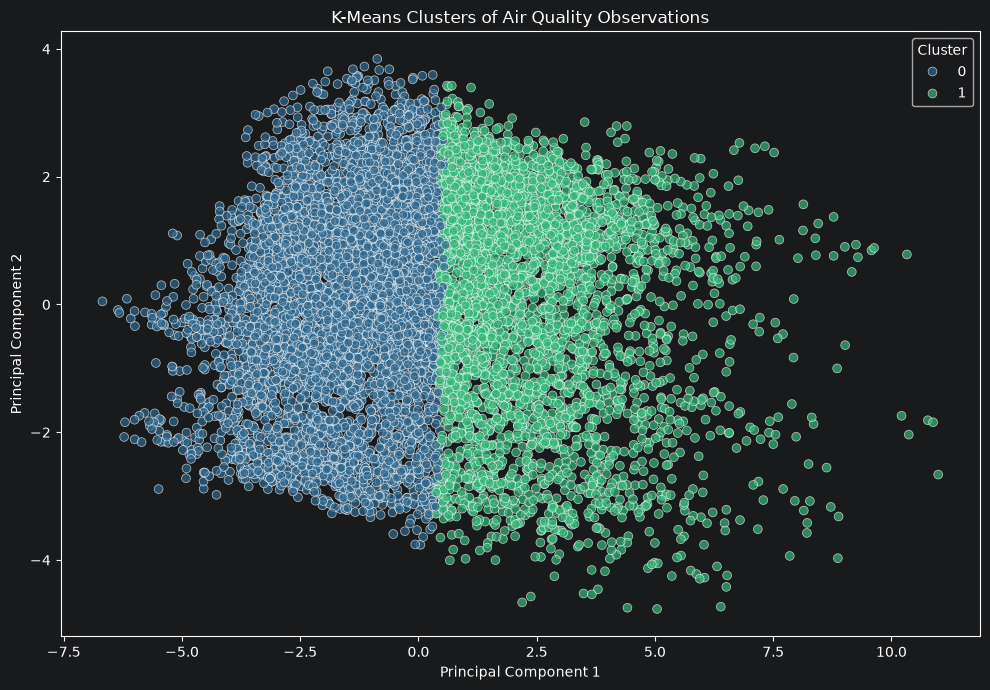


Cluster Profiles:


,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
Cluster,,,,,,,
0,1.38,148.55,93.19,5.57,17.21,49.96,0.98
1,3.21,372.84,142.86,17.07,20.02,48.12,1.09


In [7]:
# ==========================================
# TASK 6 - UNSUPERVISED LEARNING
# K-Means Clustering + PCA Visualization
# ==========================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Use the same feature set used for prediction
X_cluster = X.copy()

# Scale features for K-Means
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# ------------------------------------------
# 1. Find a suitable number of clusters
# ------------------------------------------

silhouette_results = {}

for k in range(2, 7):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(X_cluster_scaled)

    score = silhouette_score(
        X_cluster_scaled,
        labels_temp
    )

    silhouette_results[k] = score

silhouette_df = pd.DataFrame(
    {
        "K": list(silhouette_results.keys()),
        "Silhouette Score": list(silhouette_results.values())
    }
)

print("Silhouette Scores:")
display(silhouette_df.round(4))

# Choose the K with the highest silhouette score
optimal_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "K"
]

optimal_k = int(optimal_k)

print("Selected number of clusters:", optimal_k)


# ------------------------------------------
# 2. Final K-Means model
# ------------------------------------------

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_cluster_scaled
)

df_capstone = df.copy()

df_capstone["Cluster"] = cluster_labels

print("\nCluster Counts:")
print(
    df_capstone["Cluster"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------
# 3. PCA for visualization
# ------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print("\nExplained Variance:")
print(
    "PC1:",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "PC2:",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

print(
    "Total:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)


# ------------------------------------------
# 4. Cluster visualization
# ------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=40,
    alpha=0.7
)

plt.title(
    "K-Means Clusters of Air Quality Observations"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()


# ------------------------------------------
# 5. Cluster profiles
# ------------------------------------------

profile_features = [
    "CO(GT)",
    "NOx(GT)",
    "NO2(GT)",
    "C6H6(GT)",
    "T",
    "RH",
    "AH"
]

cluster_profiles = (
    df_capstone
    .groupby("Cluster")[profile_features]
    .mean()
    .round(2)
)

print("\nCluster Profiles:")
display(cluster_profiles)

In [8]:
# ==========================================
# TASK 6 - FINAL MODEL EVALUATION
# ==========================================

print("=" * 60)
print("FINAL CAPSTONE PROJECT SUMMARY")
print("=" * 60)

# ------------------------------------------
# 1. Supervised model comparison
# ------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        0.3799,
        0.2530
    ],
    "RMSE": [
        0.5590,
        0.4098
    ],
    "R2 Score": [
        0.8334,
        0.9105
    ]
})

print("\nSupervised Model Comparison:")
display(comparison)

# Determine best model
best_model = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

best_r2 = comparison["R2 Score"].max()

print(f"\nBest supervised model: {best_model}")
print(f"Best R² Score: {best_r2:.4f}")


# ------------------------------------------
# 2. Improvement over Linear Regression
# ------------------------------------------

lr_mae = comparison.loc[
    comparison["Model"] == "Linear Regression",
    "MAE"
].iloc[0]

rf_mae = comparison.loc[
    comparison["Model"] == "Random Forest",
    "MAE"
].iloc[0]

lr_rmse = comparison.loc[
    comparison["Model"] == "Linear Regression",
    "RMSE"
].iloc[0]

rf_rmse = comparison.loc[
    comparison["Model"] == "Random Forest",
    "RMSE"
].iloc[0]

lr_r2 = comparison.loc[
    comparison["Model"] == "Linear Regression",
    "R2 Score"
].iloc[0]

rf_r2 = comparison.loc[
    comparison["Model"] == "Random Forest",
    "R2 Score"
].iloc[0]

print("\nRandom Forest Improvement:")

print(
    f"MAE improvement: "
    f"{((lr_mae - rf_mae) / lr_mae) * 100:.2f}%"
)

print(
    f"RMSE improvement: "
    f"{((lr_rmse - rf_rmse) / lr_rmse) * 100:.2f}%"
)

print(
    f"R² improvement: "
    f"{((rf_r2 - lr_r2) / lr_r2) * 100:.2f}%"
)


# ------------------------------------------
# 3. Neural Network comparison
# ------------------------------------------

print("\nDeep Learning Model:")
print("PyTorch Neural Network")
print("Training epochs: 90")
print("Loss function: Mean Squared Error (MSE)")
print("Optimizer: Adam")


# ------------------------------------------
# 4. Final conclusion
# ------------------------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
This capstone project analyzed the Air Quality dataset to
understand and predict carbon monoxide (CO) concentration.

The workflow included data preparation, exploratory analysis,
feature engineering, supervised machine learning, deep learning,
and unsupervised clustering.

Linear Regression provided a strong baseline, while Random Forest
achieved better predictive performance with lower MAE and RMSE
and a higher R² score.

A PyTorch neural network was also trained to investigate whether
a deep learning approach could effectively model the nonlinear
relationships in the air-quality variables.

K-Means clustering was additionally used to identify groups of
observations with similar environmental and pollution conditions.

Overall, the project demonstrates an end-to-end data science
workflow from raw data preparation to modeling, evaluation,
interpretation, and practical environmental analysis.
""")

FINAL CAPSTONE PROJECT SUMMARY

Supervised Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.3799,0.5590,0.8334
1,Random Forest,0.2530,0.4098,0.9105



Best supervised model: Random Forest
Best R² Score: 0.9105

Random Forest Improvement:
MAE improvement: 33.40%
RMSE improvement: 26.69%
R² improvement: 9.25%

Deep Learning Model:
PyTorch Neural Network
Training epochs: 90
Loss function: Mean Squared Error (MSE)
Optimizer: Adam

CONCLUSION

This capstone project analyzed the Air Quality dataset to
understand and predict carbon monoxide (CO) concentration.

The workflow included data preparation, exploratory analysis,
feature engineering, supervised machine learning, deep learning,
and unsupervised clustering.

Linear Regression provided a strong baseline, while Random Forest
achieved better predictive performance with lower MAE and RMSE
and a higher R² score.

A PyTorch neural network was also trained to investigate whether
a deep learning approach could effectively model the nonlinear
relationships in the air-quality variables.

K-Means clustering was additionally used to identify groups of
observations with similar environmental and

Output folders ready.


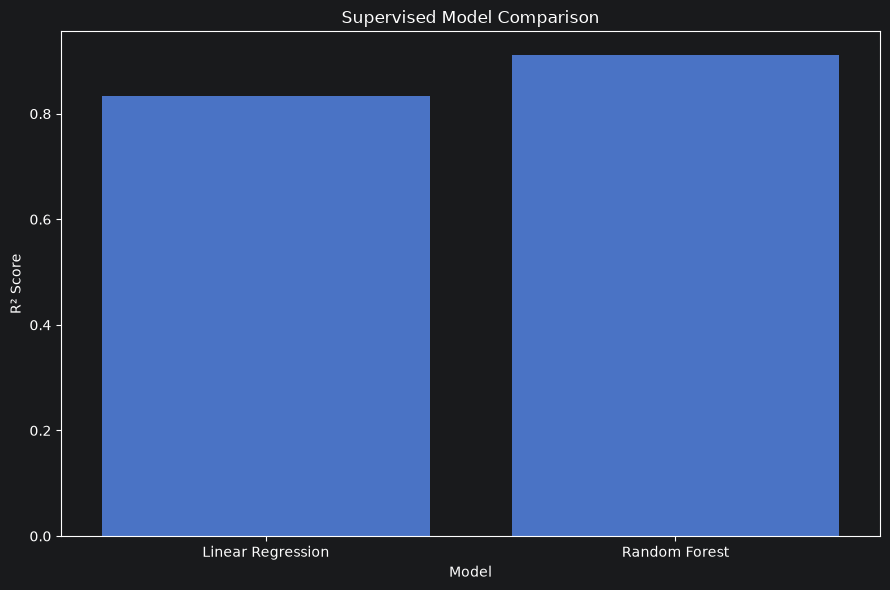

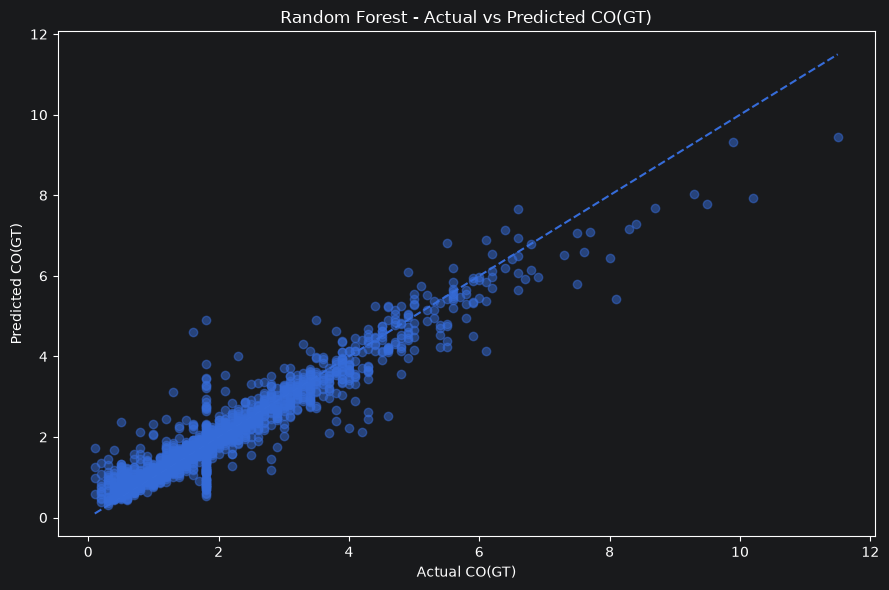

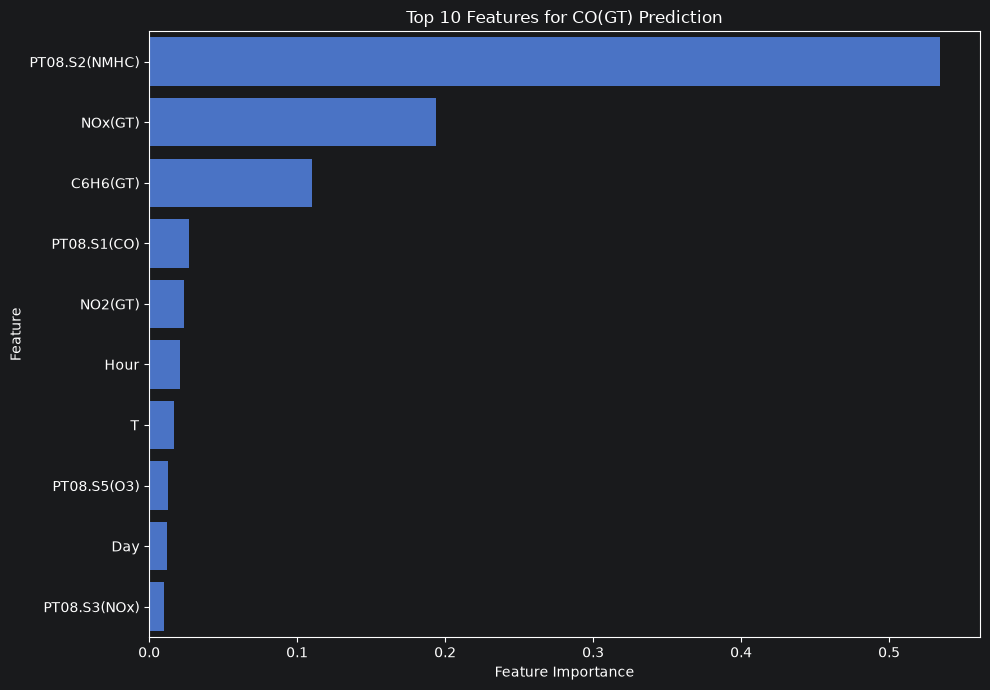

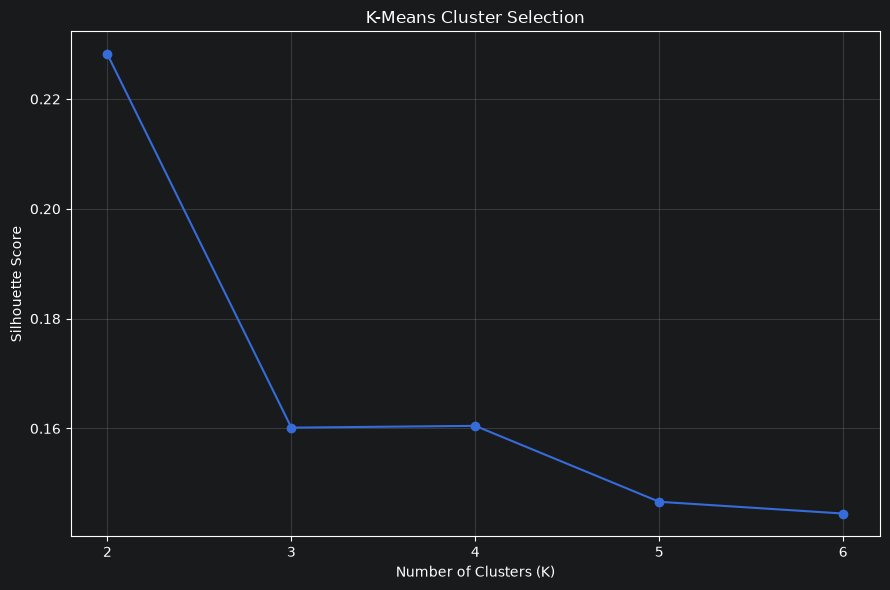

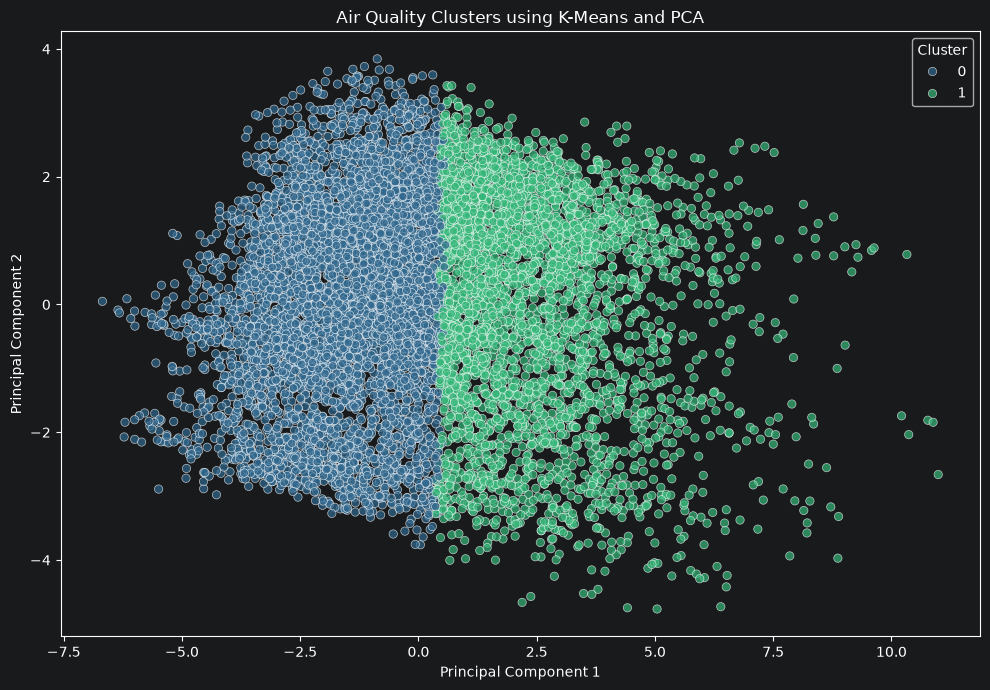


TASK 6 OUTPUTS SAVED SUCCESSFULLY
clustered_air_quality_data.csv
cluster_profiles.csv
feature_importance.csv
model_comparison.csv
model_predictions.csv
pca_clusters.csv
silhouette_scores.csv
figures\feature_importance.png
figures\kmeans_pca_clusters.png
figures\model_comparison.png
figures\random_forest_actual_vs_predicted.png
figures\silhouette_scores.png

Output directory:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task6_capstone\outputs


In [9]:
# ==========================================
# TASK 6 - SAVE ALL IMPORTANT OUTPUTS
# ==========================================

import os

# Create output folders
OUTPUT_DIR = r"C:\Users\harsh\YuvaIntern_Data_Science_Project\task6_capstone\outputs"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Output folders ready.")


# ==========================================
# 1. SAVE MODEL COMPARISON
# ==========================================

comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)


# ==========================================
# 2. SAVE CLUSTER RESULTS
# ==========================================

df_capstone.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "clustered_air_quality_data.csv"
    ),
    index=False
)


# ==========================================
# 3. SAVE CLUSTER PROFILES
# ==========================================

cluster_profiles.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cluster_profiles.csv"
    )
)


# ==========================================
# 4. SAVE SILHOUETTE SCORES
# ==========================================

silhouette_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "silhouette_scores.csv"
    ),
    index=False
)


# ==========================================
# 5. SAVE PCA CLUSTER DATA
# ==========================================

pca_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pca_clusters.csv"
    ),
    index=False
)


# ==========================================
# 6. MODEL COMPARISON FIGURE
# ==========================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Supervised Model Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 7. ACTUAL VS PREDICTED - RANDOM FOREST
# ==========================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    rf_pred.min()
)

max_value = max(
    y_test.max(),
    rf_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Random Forest - Actual vs Predicted CO(GT)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "random_forest_actual_vs_predicted.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 8. RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance.csv"
    ),
    index=False
)

plt.figure(figsize=(10, 7))

top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for CO(GT) Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 9. K-MEANS SILHOUETTE SCORE
# ==========================================

plt.figure(figsize=(9, 6))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Cluster Selection")

plt.xticks(
    silhouette_df["K"]
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "silhouette_scores.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 10. K-MEANS PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title(
    "Air Quality Clusters using K-Means and PCA"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "kmeans_pca_clusters.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 11. SAVE FINAL PREDICTIONS
# ==========================================

predictions_df = pd.DataFrame({
    "Actual_CO_GT": y_test.values,
    "Linear_Regression_Prediction": linear_pred,
    "Random_Forest_Prediction": rf_pred
})

predictions_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_predictions.csv"
    ),
    index=False
)


# ==========================================
# 12. FINAL OUTPUT LIST
# ==========================================

print("\n" + "=" * 60)
print("TASK 6 OUTPUTS SAVED SUCCESSFULLY")
print("=" * 60)

for root, dirs, files in os.walk(OUTPUT_DIR):

    for file in files:

        full_path = os.path.join(root, file)

        print(
            os.path.relpath(
                full_path,
                OUTPUT_DIR
            )
        )

print("\nOutput directory:")
print(OUTPUT_DIR)